In [1]:
import pyclara
import pandas
import matplotlib.pyplot as plt
import sdds
import numpy as np

initializing ocelot...

RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
ix = pyclara.Converters.elegant2impactx("../Run/FEBE.lte",
                                        start_element="CLA-FEA-SIM-DIP-04-END",
                                        end_element="CLA-FED-SIM-DUMP-01-START",
                                        elegant_twi="../Run/FEBE.twi")

Initializing AMReX (26.01)...
OMP initialized with 12 OMP threads
AMReX (26.01) initialized

Grids Summary:
  Level 0   1 grids  512 cells  100 % of domain

 Diagnostics: 1
 Space Charge effects: False
 CSR effects: 0
 ISR effects: 0
 Spin tracking: 0

++++ Starting step=1 slice_step=0

**** WARNINGS ******************************************************************
* GLOBAL warning list  after  [ FIRST STEP ]
*
* No recorded warnings.
********************************************************************************


++++ Starting step=2 slice_step=0

++++ Starting step=3 slice_step=0

++++ Starting step=4 slice_step=0

++++ Starting step=5 slice_step=0

++++ Starting step=6 slice_step=0

++++ Starting step=7 slice_step=0

++++ Starting step=8 slice_step=0

++++ Starting step=9 slice_step=0

++++ Starting step=10 slice_step=0

++++ Starting step=11 slice_step=0

++++ Starting step=12 slice_step=0

++++ Starting step=13 slice_step=0

++++ Starting step=14 slice_step=0

++++ Starting ste

In [3]:
df = pandas.read_csv("diags/reduced_beam_characteristics.0.0",
                     sep=r"\s+",
                     comment="#")

[383] [542] [60.449232] [83.569506]


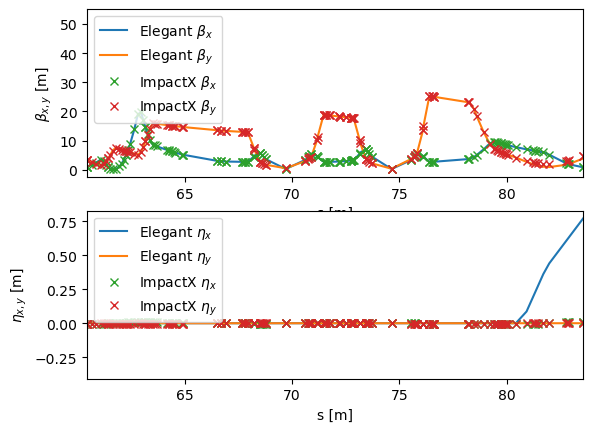

In [4]:
elegant_twi = sdds.load("../Run/FEBE.twi")

e_names = np.array(elegant_twi.getColumnValueList("ElementName"))
e_s = np.array(elegant_twi.getColumnValueList("s"))
e_betax = np.array(elegant_twi.getColumnValueList("betax"))
e_betay = np.array(elegant_twi.getColumnValueList("betay"))
e_etax = np.array(elegant_twi.getColumnValueList("etax"))
e_etay = np.array(elegant_twi.getColumnValueList("etay"))

e_idx0 = np.where(e_names == "CLA-FEA-SIM-DIP-04-END")[0] # TODO not sure about this offset 
e_idxN = np.where(e_names == "CLA-FED-SIM-DUMP-01-START")[0]

print(e_idx0, e_idxN, e_s[e_idx0], e_s[e_idxN])
plt.subplot(2,1,1)
plt.plot(e_s, e_betax, label="Elegant $\\beta_x$")
plt.plot(e_s, e_betay, label="Elegant $\\beta_y$")
plt.plot(df['s'] + e_s[e_idx0],df['beta_x'],"x", label="ImpactX $\\beta_x$")
plt.plot(df['s'] + e_s[e_idx0],df['beta_y'],"x", label="ImpactX $\\beta_y$")
plt.xlabel("s [m]")
plt.ylabel("$\\beta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);
plt.legend()

plt.subplot(2,1,2)
plt.plot(e_s, e_etax, label="Elegant $\\eta_x$")
plt.plot(e_s, e_etay, label="Elegant $\\eta_y$")
plt.plot(df['s'] + e_s[e_idx0],df['dispersion_x'],"x", label="ImpactX $\\eta_x$")
plt.plot(df['s'] + e_s[e_idx0],df['dispersion_y'],"x", label="ImpactX $\\eta_y$")
plt.xlabel("s [m]")
plt.ylabel("$\\eta_{x,y}$ [m]");
plt.xlim(e_s[e_idx0], e_s[e_idxN]);
plt.legend(loc=2)

plt.savefig("ImpactX_ElegantComparision.jpg")